# 股票技术指标计算过程

> **三一重工 (600031.SH) & 平安集团 (000001.SZ)** ｜ 数据诊断 · 指标计算 · 可视化

本 Notebook 以 **分步骤、可交互** 的方式展示四大技术指标的完整计算过程：

| 指标 | 类型 | 核心作用 |
|------|------|----------|
| **RSI** (相对强弱指数) | 动量指标 | 判断超买超卖，>70 超买，<30 超卖 |
| **MACD** (指数平滑异同移动平均线) | 趋势指标 | 金叉买入、死叉卖出，判断趋势方向 |
| **布林带** (Bollinger Bands) | 波动率指标 | 价格通道，触及上下轨判断回调/反弹 |
| **KDJ** (随机指标) | 动量振荡 | 短线超买超卖，灵敏捕捉转折点 |

---

## 1. 环境准备与数据加载

导入所需库，加载两只股票的日线行情数据。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# 全局绘图设置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print('环境准备完成 pandas={}, numpy={}'.format(pd.__version__, np.__version__))

环境准备完成 pandas=2.3.1, numpy=2.2.6


### 1.1 定义数据加载函数

读取 CSV 文件，将 `trade_date` 解析为日期类型，按日期升序排列。

In [2]:
def load_data(filepath):
    """加载CSV数据，解析日期，按日期升序排列"""
    df = pd.read_csv(filepath)
    df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
    df = df.sort_values('trade_date').reset_index(drop=True)
    return df

# 加载两只股票数据
df_sany = load_data('三一重工行情数据.csv')
df_pingan = load_data('平安集团行情数据.csv')

print(f'三一重工: {len(df_sany)} 条记录, {df_sany["trade_date"].min().date()} ~ {df_sany["trade_date"].max().date()}')
print(f'平安集团: {len(df_pingan)} 条记录, {df_pingan["trade_date"].min().date()} ~ {df_pingan["trade_date"].max().date()}')

三一重工: 129 条记录, 2025-01-02 ~ 2025-07-16
平安集团: 372 条记录, 2024-01-02 ~ 2025-07-17


### 1.2 数据预览

In [3]:
# 三一重工前5行
df_sany.head()

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,600031.SH,2025-01-02,16.48,16.48,15.69,15.77,16.48,-0.71,-4.3083,853894.28,1368558.133
1,600031.SH,2025-01-03,15.85,16.00,15.55,15.60,15.77,-0.17,-1.0780,534033.71,842151.570
2,600031.SH,2025-01-06,15.60,15.71,15.42,15.58,15.60,-0.02,-0.1282,454873.82,707452.833
3,600031.SH,2025-01-07,15.59,15.64,15.43,15.52,15.58,-0.06,-0.3851,393682.19,611079.078
4,600031.SH,2025-01-08,15.57,15.71,15.26,15.57,15.52,0.05,0.3222,573354.64,888892.453


In [4]:
# 平安集团前5行
df_pingan.head()

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,000001.SZ,2024-01-02,9.39,9.42,9.21,9.21,9.39,-0.18,-1.9169,1158366.45,1075742.252
1,000001.SZ,2024-01-03,9.19,9.22,9.15,9.20,9.21,-0.01,-0.1086,733610.31,673673.614
2,000001.SZ,2024-01-04,9.19,9.19,9.08,9.11,9.20,-0.09,-0.9783,864193.99,787470.082
3,000001.SZ,2024-01-05,9.10,9.44,9.07,9.27,9.11,0.16,1.7563,1991622.16,1852659.692
4,000001.SZ,2024-01-08,9.23,9.30,9.11,9.15,9.27,-0.12,-1.2945,1121156.19,1029006.549


## 2. 数据基础诊断

检查缺失值，计算描述性统计量，评估数据质量。

### 2.1 缺失值检查

In [5]:
# 三一重工缺失值检查
print('=== 三一重工 缺失值检查 ===')
print(df_sany.isnull().sum())
print()
print('=== 平安集团 缺失值检查 ===')
print(df_pingan.isnull().sum())

=== 三一重工 缺失值检查 ===
ts_code       0
trade_date    0
open          0
high          0
low           0
close         0
pre_close     0
change        0
pct_chg       0
vol           0
amount        0
dtype: int64

=== 平安集团 缺失值检查 ===
ts_code       0
trade_date    0
open          0
high          0
low           0
close         0
pre_close     0
change        0
pct_chg       0
vol           0
amount        0
dtype: int64


> ✅ 两只股票数据均 **无缺失值**，数据完整。

### 2.2 描述性统计

In [6]:
# 三一重工描述性统计
stat_cols = ['open', 'high', 'low', 'close', 'vol', 'amount', 'pct_chg']
df_sany[stat_cols].describe().round(2)

,open,high,low,close,vol,amount,pct_chg
count,129.00,129.00,129.00,129.00,129.00,129.00,129.00
mean,18.24,18.46,18.04,18.25,612098.49,1127768.77,0.13
std,1.37,1.38,1.35,1.36,340872.82,673495.40,1.68
min,15.31,15.54,15.23,15.31,222382.54,388409.77,-5.76
25%,17.60,17.76,17.32,17.66,381040.22,683478.34,-0.81
50%,18.45,18.88,18.34,18.55,493317.92,869586.77,0.00
75%,19.20,19.40,18.96,19.19,705108.88,1347148.46,0.90
max,20.50,20.75,20.23,20.54,2198570.11,4353081.53,6.28


In [7]:
# 平安集团描述性统计
df_pingan[stat_cols].describe().round(2)

,open,high,low,close,vol,amount,pct_chg
count,372.00,372.00,372.00,372.00,372.00,372.00,372.00
mean,10.94,11.05,10.85,10.95,1320700.03,1458609.32,0.12
std,0.84,0.86,0.83,0.84,753730.34,883746.66,1.49
min,9.05,9.18,8.96,9.09,353013.46,353251.35,-9.32
25%,10.30,10.38,10.22,10.32,864398.18,933270.28,-0.60
50%,11.04,11.16,10.99,11.08,1108878.71,1232555.16,0.04
75%,11.55,11.65,11.47,11.55,1528486.86,1666095.71,0.83
max,13.43,13.43,12.89,13.18,5888977.78,7602664.02,9.98


**诊断结论：** 三一重工数据覆盖 2025 年上半年（129条），平安集团覆盖 2024 全年至 2025 年中（372条）。
平安集团波动性更大（单日最大涨跌幅 ±9.98%/-9.32%），三一重工相对平稳（±6.28%/-5.76%）。

---

## 3. RSI — 相对强弱指数计算过程

> **发明者:** J. Welles Wilder (1978) ｜ **常用周期:** 14天

**公式：**

$$RS = \frac{n日平均涨幅}{n日平均跌幅}, \quad RSI = 100 - \frac{100}{1+RS}$$

**作用：** RSI > 70 超买（可能回调），RSI < 30 超卖（可能反弹）。

### Step 1: 计算每日价格变动

In [8]:
# 以三一重工为例，展示 RSI 计算的每一步
close = df_sany['close'].copy()

# Step 1: 价格变动
delta = close.diff()
print('前10个价格变动：')
pd.DataFrame({'close': close, 'delta': delta}).head(10)

前10个价格变动：


,close,delta
0,15.77,NaN
1,15.60,-0.17
2,15.58,-0.02
3,15.52,-0.06
4,15.57,0.05
5,15.37,-0.20
6,15.44,0.07
7,15.31,-0.13
8,15.80,0.49
9,15.40,-0.40


### Step 2: 分离涨幅和跌幅

In [9]:
# Step 2: 分离涨跌
gain = delta.clip(lower=0)    # 涨幅（跌的日子记为0）
loss = -delta.clip(upper=0)   # 跌幅（涨的日子记为0，取绝对值）

preview = pd.DataFrame({'close': close, 'delta': delta, 'gain': gain, 'loss': loss})
preview.head(10)

,close,delta,gain,loss
0,15.77,NaN,NaN,NaN
1,15.60,-0.17,0.00,0.17
2,15.58,-0.02,0.00,0.02
3,15.52,-0.06,0.00,0.06
4,15.57,0.05,0.05,-0.00
5,15.37,-0.20,0.00,0.20
6,15.44,0.07,0.07,-0.00
7,15.31,-0.13,0.00,0.13
8,15.80,0.49,0.49,-0.00
9,15.40,-0.40,0.00,0.40


### Step 3: Wilder 平滑法计算平均涨跌幅

Wilder 平滑法（也称修正移动平均）：
- 首个值 = 前 n 日简单平均
- 后续值 = (前一日均值 × (n-1) + 当日值) / n

In [10]:
period = 14

avg_gain = pd.Series(index=close.index, dtype=float)
avg_loss = pd.Series(index=close.index, dtype=float)

# 首值用简单平均
avg_gain.iloc[period] = gain.iloc[1:period+1].mean()
avg_loss.iloc[period] = loss.iloc[1:period+1].mean()

# 后续用 Wilder 平滑
for i in range(period+1, len(close)):
    avg_gain.iloc[i] = (avg_gain.iloc[i-1] * (period-1) + gain.iloc[i]) / period
    avg_loss.iloc[i] = (avg_loss.iloc[i-1] * (period-1) + loss.iloc[i]) / period

print(f'初始平均涨幅: {avg_gain.iloc[period]:.4f}')
print(f'初始平均跌幅: {avg_loss.iloc[period]:.4f}')
print()
pd.DataFrame({'gain': gain, 'loss': loss, 'avg_gain': avg_gain, 'avg_loss': avg_loss}).iloc[period:period+10]

初始平均涨幅: 0.1100
初始平均跌幅: 0.0864



,gain,loss,avg_gain,avg_loss
14,0.00,0.11,0.110000,0.086429
15,0.00,0.03,0.102143,0.082398
16,0.13,-0.00,0.104133,0.076512
17,0.00,0.10,0.096695,0.078190
18,0.00,0.29,0.089788,0.093319
19,0.00,0.05,0.083374,0.090225
20,0.99,-0.00,0.148133,0.083780
21,0.24,-0.00,0.154695,0.077796
22,0.00,0.11,0.143646,0.080096
23,0.11,-0.00,0.141242,0.074375


### Step 4: 计算 RS 和 RSI

In [11]:
# Step 4: RS = avg_gain / avg_loss, RSI = 100 - 100/(1+RS)
rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))
rsi.iloc[:period] = np.nan  # 前14天无值

print('最近10日 RSI 值：')
pd.DataFrame({'close': close, 'RS': rs, 'RSI': rsi}).tail(10).round(2)

最近10日 RSI 值：


,close,RS,RSI
119,18.16,1.01,50.32
120,18.23,1.08,51.87
121,18.35,1.20,54.49
122,19.07,1.97,66.31
123,19.11,2.01,66.83
124,18.92,1.63,61.98
125,18.83,1.49,59.76
126,18.74,1.36,57.55
127,18.90,1.52,60.36
128,18.71,1.25,55.65


### Step 5: RSI 可视化

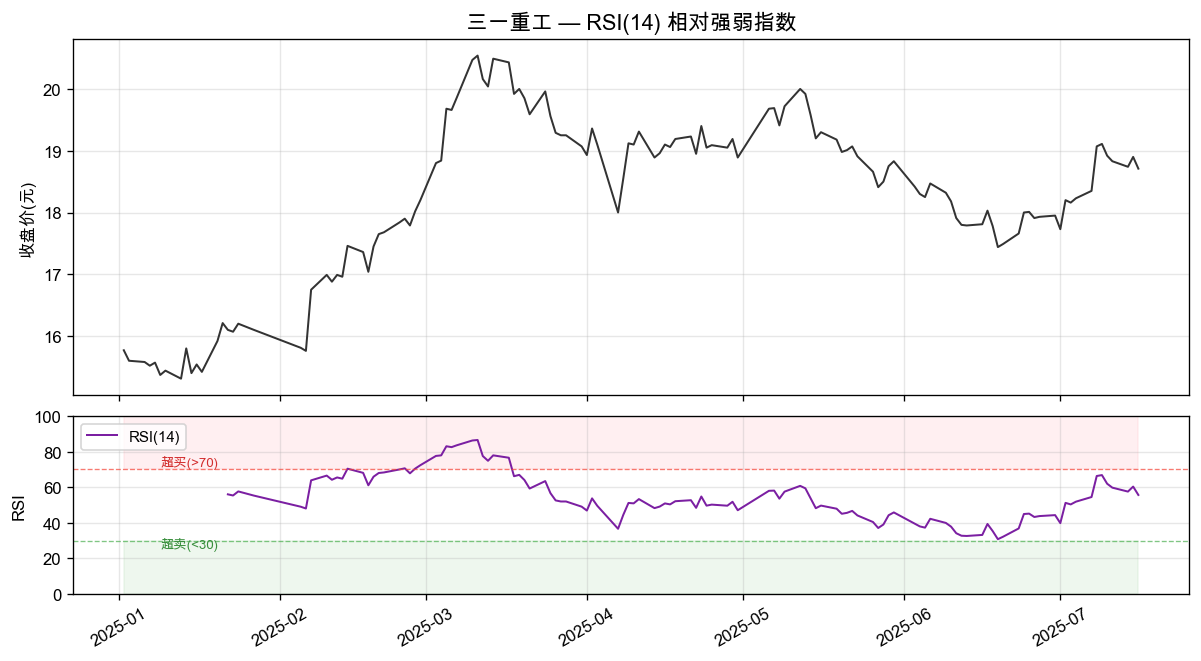

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), height_ratios=[2, 1],
                                sharex=True, gridspec_kw={'hspace': 0.08})

ax1.plot(df_sany['trade_date'], close, color='#333', linewidth=1.2)
ax1.set_ylabel('收盘价(元)')
ax1.set_title('三一重工 — RSI(14) 相对强弱指数', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(df_sany['trade_date'], rsi, color='#7B1FA2', linewidth=1.2, label='RSI(14)')
ax2.axhline(70, color='#F44336', linewidth=0.8, linestyle='--', alpha=0.7)
ax2.axhline(30, color='#4CAF50', linewidth=0.8, linestyle='--', alpha=0.7)
ax2.fill_between(df_sany['trade_date'], 70, 100, color='#FFCDD2', alpha=0.3)
ax2.fill_between(df_sany['trade_date'], 0, 30, color='#C8E6C9', alpha=0.3)
ax2.text(df_sany['trade_date'].iloc[5], 72, '超买(>70)', fontsize=8, color='#D32F2F')
ax2.text(df_sany['trade_date'].iloc[5], 26, '超卖(<30)', fontsize=8, color='#388E3C')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('三一重工_RSI.png', bbox_inches='tight')
plt.show()

---

## 4. MACD — 指数平滑异同移动平均线计算过程

> **发明者:** Gerald Appel (1979) ｜ **参数:** 12, 26, 9

**公式：**

$$DIF = EMA(12) - EMA(26)$$
$$DEA = EMA(DIF, 9)$$
$$MACD_{柱} = 2 \times (DIF - DEA)$$

**作用：** DIF 上穿 DEA → 金叉买入；DIF 下穿 DEA → 死叉卖出。

### Step 1: 计算 EMA(12) 和 EMA(26)

EMA（指数移动平均）赋予近期数据更大权重：

$$EMA_t = Close_t \times \frac{2}{n+1} + EMA_{t-1} \times \frac{n-1}{n+1}$$

In [13]:
# 使用 pandas ewm 计算 EMA
ema_fast = close.ewm(span=12, adjust=False).mean()   # EMA(12)
ema_slow = close.ewm(span=26, adjust=False).mean()   # EMA(26)

print('前10行 EMA 对比：')
pd.DataFrame({'close': close, 'EMA12': ema_fast, 'EMA26': ema_slow}).head(10).round(4)

前10行 EMA 对比：


,close,EMA12,EMA26
0,15.77,15.7700,15.7700
1,15.60,15.7438,15.7574
2,15.58,15.7186,15.7443
3,15.52,15.6881,15.7277
4,15.57,15.6699,15.7160
5,15.37,15.6238,15.6903
6,15.44,15.5955,15.6718
7,15.31,15.5516,15.6450
8,15.80,15.5898,15.6565
9,15.40,15.5606,15.6375


### Step 2: 计算 DIF（差离值）

In [14]:
dif = ema_fast - ema_slow

print('DIF 统计：')
print(f'  均值: {dif.mean():.4f}')
print(f'  最大: {dif.max():.4f}')
print(f'  最小: {dif.min():.4f}')
print()
pd.DataFrame({'close': close, 'EMA12': ema_fast, 'EMA26': ema_slow, 'DIF': dif}).tail(10).round(4)

DIF 统计：
  均值: 0.1391
  最大: 0.9908
  最小: -0.3759



,close,EMA12,EMA26,DIF
119,18.16,17.9738,18.1322,-0.1584
120,18.23,18.0132,18.1394,-0.1262
121,18.35,18.0650,18.1550,-0.0900
122,19.07,18.2196,18.2228,-0.0031
123,19.11,18.3566,18.2885,0.0681
124,18.92,18.4433,18.3353,0.1080
125,18.83,18.5028,18.3719,0.1309
126,18.74,18.5393,18.3992,0.1401
127,18.90,18.5948,18.4363,0.1585
128,18.71,18.6125,18.4566,0.1559


### Step 3: 计算 DEA（讯号线 = DIF 的 9日 EMA）

In [15]:
dea = dif.ewm(span=9, adjust=False).mean()

pd.DataFrame({'DIF': dif, 'DEA': dea}).tail(10).round(4)

,DIF,DEA
119,-0.1584,-0.2395
120,-0.1262,-0.2168
121,-0.0900,-0.1914
122,-0.0031,-0.1538
123,0.0681,-0.1094
124,0.1080,-0.0659
125,0.1309,-0.0266
126,0.1401,0.0068
127,0.1585,0.0371
128,0.1559,0.0609


### Step 4: 计算 MACD 柱状图

国内习惯：$MACD_{柱} = 2 \times (DIF - DEA)$

In [16]:
macd_hist = 2 * (dif - dea)

print('最近10日 MACD 三线值：')
pd.DataFrame({'close': close, 'DIF': dif, 'DEA': dea, 'MACD柱': macd_hist}).tail(10).round(4)

最近10日 MACD 三线值：


,close,DIF,DEA,MACD柱
119,18.16,-0.1584,-0.2395,0.1622
120,18.23,-0.1262,-0.2168,0.1813
121,18.35,-0.0900,-0.1914,0.2029
122,19.07,-0.0031,-0.1538,0.3013
123,19.11,0.0681,-0.1094,0.3550
124,18.92,0.1080,-0.0659,0.3479
125,18.83,0.1309,-0.0266,0.3148
126,18.74,0.1401,0.0068,0.2666
127,18.90,0.1585,0.0371,0.2428
128,18.71,0.1559,0.0609,0.1901


### Step 5: MACD 可视化

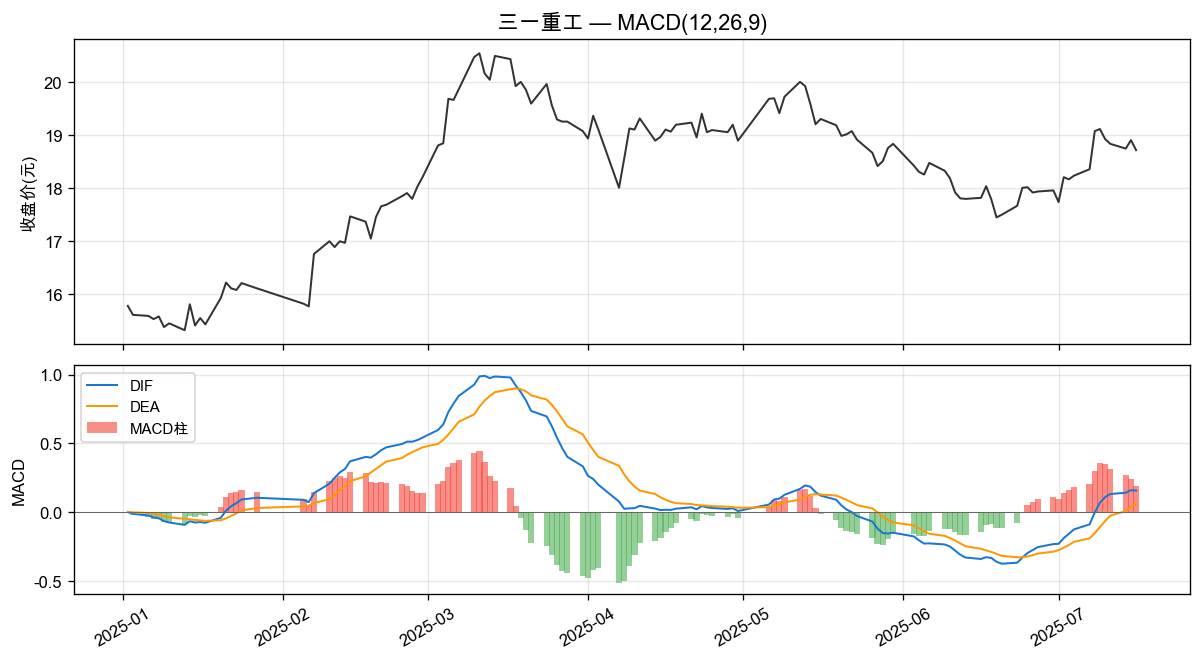

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), height_ratios=[2, 1.5],
                                sharex=True, gridspec_kw={'hspace': 0.08})

ax1.plot(df_sany['trade_date'], close, color='#333', linewidth=1.2)
ax1.set_ylabel('收盘价(元)')
ax1.set_title('三一重工 — MACD(12,26,9)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

colors = ['#F44336' if v >= 0 else '#4CAF50' for v in macd_hist]
ax2.bar(df_sany['trade_date'], macd_hist, color=colors, width=1.2, alpha=0.6, label='MACD柱')
ax2.plot(df_sany['trade_date'], dif, color='#1976D2', linewidth=1.2, label='DIF')
ax2.plot(df_sany['trade_date'], dea, color='#FF9800', linewidth=1.2, label='DEA')
ax2.axhline(0, color='#666', linewidth=0.6)
ax2.set_ylabel('MACD')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('三一重工_MACD.png', bbox_inches='tight')
plt.show()

---

## 5. 布林带 — Bollinger Bands 计算过程

> **发明者:** John Bollinger (1980s) ｜ **参数:** 20日, 2倍标准差

**公式：**

$$中轨 = MA(close, 20)$$
$$上轨 = 中轨 + 2 \times \sigma$$
$$下轨 = 中轨 - 2 \times \sigma$$

**作用：** 触及上轨可能超买，触及下轨可能超卖；带宽收口预示突破。

### Step 1: 计算中轨 MA(20)

In [18]:
window = 20
boll_ma = close.rolling(window=window).mean()

print('前25行中轨（前19天为NaN）：')
pd.DataFrame({'close': close, 'BOLL_MA': boll_ma}).head(25).round(4)

前25行中轨（前19天为NaN）：


,close,BOLL_MA
0,15.77,NaN
1,15.60,NaN
2,15.58,NaN
3,15.52,NaN
4,15.57,NaN
5,15.37,NaN
6,15.44,NaN
7,15.31,NaN
8,15.80,NaN
9,15.40,NaN


### Step 2: 计算标准差 SD(20)

In [19]:
boll_std = close.rolling(window=window).std()

pd.DataFrame({'close': close, 'BOLL_MA': boll_ma, 'BOLL_STD': boll_std}).tail(10).round(4)

,close,BOLL_MA,BOLL_STD
119,18.16,17.9285,0.2590
120,18.23,17.9165,0.2372
121,18.35,17.9180,0.2400
122,19.07,17.9625,0.3489
123,19.11,18.0225,0.4326
124,18.92,18.0785,0.4729
125,18.83,18.1305,0.4961
126,18.74,18.1770,0.5079
127,18.90,18.2205,0.5314
128,18.71,18.2670,0.5315


### Step 3: 计算上轨和下轨

In [20]:
num_std = 2
boll_upper = boll_ma + num_std * boll_std
boll_lower = boll_ma - num_std * boll_std

print('最近10日布林带三轨：')
pd.DataFrame({
    'close': close, 'BOLL下轨': boll_lower, 'BOLL中轨': boll_ma, 'BOLL上轨': boll_upper
}).tail(10).round(2)

最近10日布林带三轨：


,close,BOLL下轨,BOLL中轨,BOLL上轨
119,18.16,17.41,17.93,18.45
120,18.23,17.44,17.92,18.39
121,18.35,17.44,17.92,18.40
122,19.07,17.26,17.96,18.66
123,19.11,17.16,18.02,18.89
124,18.92,17.13,18.08,19.02
125,18.83,17.14,18.13,19.12
126,18.74,17.16,18.18,19.19
127,18.90,17.16,18.22,19.28
128,18.71,17.20,18.27,19.33


### Step 4: 计算带宽 Bandwidth

$$带宽 = \frac{上轨 - 下轨}{中轨} \times 100\%$$

In [21]:
boll_bw = (boll_upper - boll_lower) / boll_ma * 100

print(f'带宽统计: 均值={boll_bw.mean():.2f}%, 最大={boll_bw.max():.2f}%, 最小={boll_bw.min():.2f}%')
print()
pd.DataFrame({'close': close, '带宽(%)': boll_bw}).tail(10).round(2)

带宽统计: 均值=11.81%, 最大=25.85%, 最小=5.30%



,close,带宽(%)
119,18.16,5.78
120,18.23,5.30
121,18.35,5.36
122,19.07,7.77
123,19.11,9.60
124,18.92,10.46
125,18.83,10.94
126,18.74,11.18
127,18.90,11.67
128,18.71,11.64


### Step 5: 布林带可视化

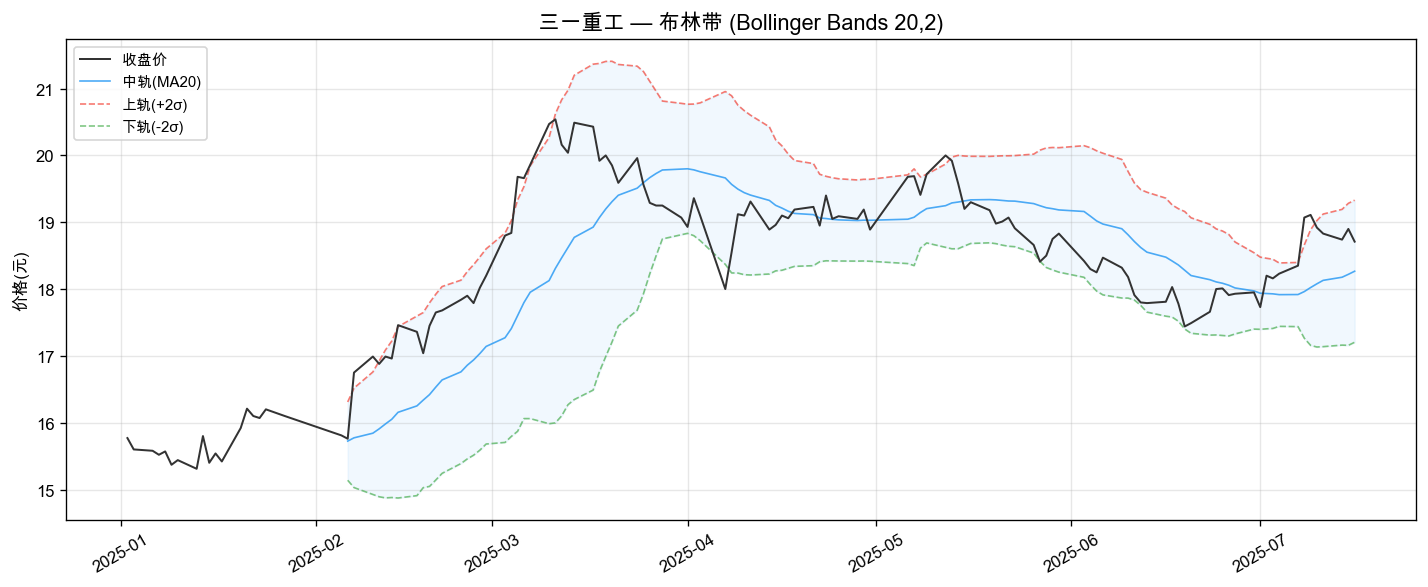

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_sany['trade_date'], close, color='#333', linewidth=1.2, label='收盘价', zorder=3)
ax.plot(df_sany['trade_date'], boll_ma, color='#2196F3', linewidth=1, label='中轨(MA20)', alpha=0.8)
ax.plot(df_sany['trade_date'], boll_upper, color='#F44336', linewidth=1, linestyle='--', label='上轨(+2σ)', alpha=0.7)
ax.plot(df_sany['trade_date'], boll_lower, color='#4CAF50', linewidth=1, linestyle='--', label='下轨(-2σ)', alpha=0.7)
ax.fill_between(df_sany['trade_date'], boll_upper, boll_lower, color='#90CAF9', alpha=0.12)

ax.set_title('三一重工 — 布林带 (Bollinger Bands 20,2)', fontsize=13, fontweight='bold')
ax.set_ylabel('价格(元)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('三一重工_布林带.png', bbox_inches='tight')
plt.show()

---

## 6. KDJ — 随机指标计算过程（扩展指标）

> **参数:** 9, 3, 3 ｜ 中国市场最常用的短线指标之一

**公式：**

$$RSV = \frac{Close - LowestLow(9)}{HighestHigh(9) - LowestLow(9)} \times 100$$
$$K_t = \frac{2}{3}K_{t-1} + \frac{1}{3}RSV_t$$
$$D_t = \frac{2}{3}D_{t-1} + \frac{1}{3}K_t$$
$$J = 3K - 2D$$

**作用：** K/D > 80 超买，< 20 超卖；J > 100 极度超买，J < 0 极度超卖。

**其他典型指标概览：** OBV(能量潮)、CCI(顺势指标)、ATR(真实波幅)、WR(威廉指标)、DMI(趋向指标)、SAR(抛物线指标)。

### Step 1: 计算 RSV（未成熟随机值）

In [23]:
high = df_sany['high'].copy()
low = df_sany['low'].copy()

n = 9
lowest_low = low.rolling(window=n).min()
highest_high = high.rolling(window=n).max()
rsv = (close - lowest_low) / (highest_high - lowest_low) * 100
rsv = rsv.fillna(50)  # 不足9天时填充50

print('前12行 RSV 计算：')
pd.DataFrame({'high': high, 'low': low, 'close': close,
              'LL(9)': lowest_low, 'HH(9)': highest_high, 'RSV': rsv}).head(12).round(2)

前12行 RSV 计算：


,high,low,close,LL(9),HH(9),RSV
0,16.48,15.69,15.77,NaN,NaN,50.00
1,16.00,15.55,15.60,NaN,NaN,50.00
2,15.71,15.42,15.58,NaN,NaN,50.00
3,15.64,15.43,15.52,NaN,NaN,50.00
4,15.71,15.26,15.57,NaN,NaN,50.00
5,15.56,15.32,15.37,NaN,NaN,50.00
6,15.71,15.38,15.44,NaN,NaN,50.00
7,15.70,15.23,15.31,NaN,NaN,50.00
8,15.85,15.30,15.80,15.23,16.48,45.60
9,15.80,15.38,15.40,15.23,16.00,22.08


### Step 2: 计算 K 值（RSV 的 3日加权移动平均）

In [24]:
m1 = 3
k = pd.Series(index=close.index, dtype=float)
k.iloc[0] = 50  # 初始值

for i in range(1, len(close)):
    k.iloc[i] = (m1 - 1) / m1 * k.iloc[i-1] + 1 / m1 * rsv.iloc[i]

print('K 值前12行：')
pd.DataFrame({'RSV': rsv, 'K': k}).head(12).round(2)

K 值前12行：


,RSV,K
0,50.00,50.00
1,50.00,50.00
2,50.00,50.00
3,50.00,50.00
4,50.00,50.00
5,50.00,50.00
6,50.00,50.00
7,50.00,50.00
8,45.60,48.53
9,22.08,39.71


### Step 3: 计算 D 值（K 的 3日加权移动平均）

In [25]:
m2 = 3
d = pd.Series(index=close.index, dtype=float)
d.iloc[0] = 50

for i in range(1, len(close)):
    d.iloc[i] = (m2 - 1) / m2 * d.iloc[i-1] + 1 / m2 * k.iloc[i]

pd.DataFrame({'RSV': rsv, 'K': k, 'D': d}).head(12).round(2)

,RSV,K,D
0,50.00,50.00,50.00
1,50.00,50.00,50.00
2,50.00,50.00,50.00
3,50.00,50.00,50.00
4,50.00,50.00,50.00
5,50.00,50.00,50.00
6,50.00,50.00,50.00
7,50.00,50.00,50.00
8,45.60,48.53,49.51
9,22.08,39.71,46.25


### Step 4: 计算 J 值

$$J = 3K - 2D$$

J 值可超出 0-100 范围（理论 -100~200），这是 KDJ 区别于 RSI 的特点。

In [26]:
j = 3 * k - 2 * d

print('最近10日 KDJ 值：')
pd.DataFrame({'close': close, 'K': k, 'D': d, 'J': j}).tail(10).round(2)

最近10日 KDJ 值：


,close,K,D,J
119,18.16,72.22,65.37,85.92
120,18.23,74.37,68.37,86.37
121,18.35,81.13,72.62,98.16
122,19.07,87.19,77.48,106.61
123,19.11,89.34,81.43,105.15
124,18.92,85.73,82.87,91.47
125,18.83,81.49,82.41,79.66
126,18.74,76.19,80.34,67.90
127,18.90,74.02,78.23,65.59
128,18.71,67.38,74.61,52.91


### Step 5: KDJ 可视化

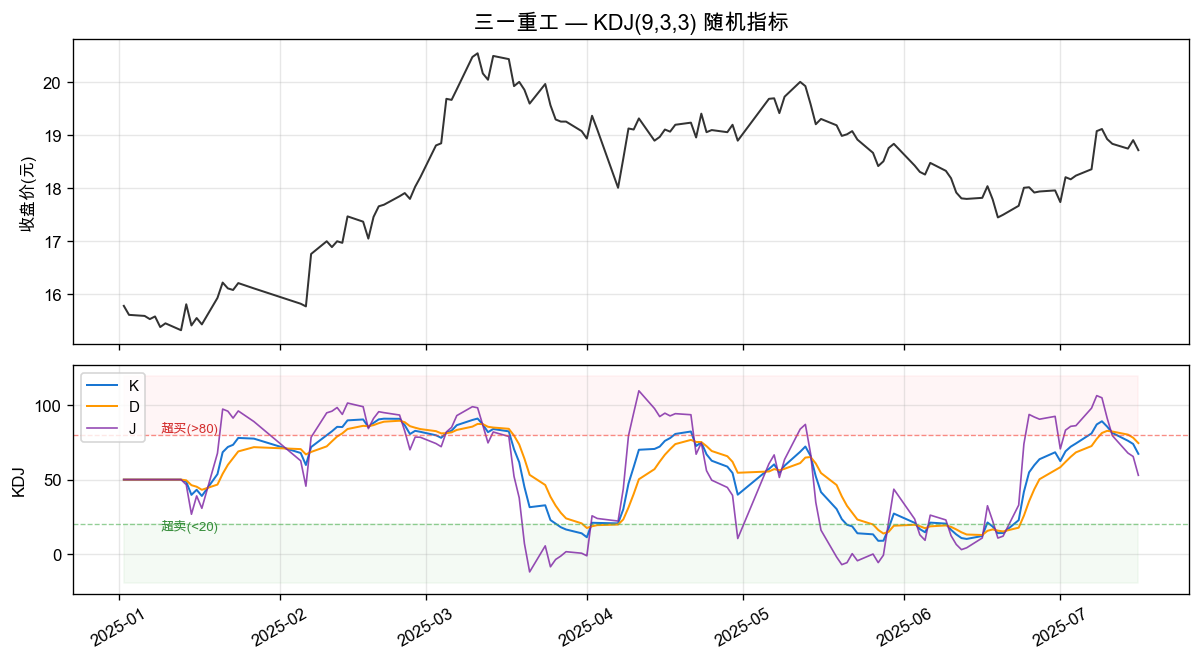

In [27]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), height_ratios=[2, 1.5],
                                sharex=True, gridspec_kw={'hspace': 0.08})

ax1.plot(df_sany['trade_date'], close, color='#333', linewidth=1.2)
ax1.set_ylabel('收盘价(元)')
ax1.set_title('三一重工 — KDJ(9,3,3) 随机指标', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(df_sany['trade_date'], k, color='#1976D2', linewidth=1.2, label='K')
ax2.plot(df_sany['trade_date'], d, color='#FF9800', linewidth=1.2, label='D')
ax2.plot(df_sany['trade_date'], j, color='#7B1FA2', linewidth=1, label='J', alpha=0.8)
ax2.axhline(80, color='#F44336', linewidth=0.8, linestyle='--', alpha=0.6)
ax2.axhline(20, color='#4CAF50', linewidth=0.8, linestyle='--', alpha=0.6)
ax2.fill_between(df_sany['trade_date'], 80, 120, color='#FFCDD2', alpha=0.2)
ax2.fill_between(df_sany['trade_date'], -20, 20, color='#C8E6C9', alpha=0.2)
ax2.text(df_sany['trade_date'].iloc[5], 82, '超买(>80)', fontsize=8, color='#D32F2F')
ax2.text(df_sany['trade_date'].iloc[5], 16, '超卖(<20)', fontsize=8, color='#388E3C')
ax2.set_ylabel('KDJ')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('三一重工_KDJ.png', bbox_inches='tight')
plt.show()

---

## 7. 平安集团指标计算与综合可视化

对平安集团数据执行同样的指标计算，并绘制综合视图。

In [28]:
# 平安集团完整指标计算
close_pa = df_pingan['close'].copy()
high_pa = df_pingan['high'].copy()
low_pa = df_pingan['low'].copy()

# --- RSI ---
delta_pa = close_pa.diff()
gain_pa = delta_pa.clip(lower=0)
loss_pa = -delta_pa.clip(upper=0)
avg_gain_pa = pd.Series(index=close_pa.index, dtype=float)
avg_loss_pa = pd.Series(index=close_pa.index, dtype=float)
avg_gain_pa.iloc[14] = gain_pa.iloc[1:15].mean()
avg_loss_pa.iloc[14] = loss_pa.iloc[1:15].mean()
for i in range(15, len(close_pa)):
    avg_gain_pa.iloc[i] = (avg_gain_pa.iloc[i-1] * 13 + gain_pa.iloc[i]) / 14
    avg_loss_pa.iloc[i] = (avg_loss_pa.iloc[i-1] * 13 + loss_pa.iloc[i]) / 14
rsi_pa = 100 - 100 / (1 + avg_gain_pa / avg_loss_pa)
rsi_pa.iloc[:14] = np.nan

# --- MACD ---
dif_pa = close_pa.ewm(span=12, adjust=False).mean() - close_pa.ewm(span=26, adjust=False).mean()
dea_pa = dif_pa.ewm(span=9, adjust=False).mean()
macd_hist_pa = 2 * (dif_pa - dea_pa)

# --- 布林带 ---
boll_ma_pa = close_pa.rolling(20).mean()
boll_std_pa = close_pa.rolling(20).std()
boll_upper_pa = boll_ma_pa + 2 * boll_std_pa
boll_lower_pa = boll_ma_pa - 2 * boll_std_pa

# --- KDJ ---
ll_pa = low_pa.rolling(9).min()
hh_pa = high_pa.rolling(9).max()
rsv_pa = ((close_pa - ll_pa) / (hh_pa - ll_pa) * 100).fillna(50)
k_pa = pd.Series(index=close_pa.index, dtype=float)
d_pa = pd.Series(index=close_pa.index, dtype=float)
k_pa.iloc[0] = 50; d_pa.iloc[0] = 50
for i in range(1, len(close_pa)):
    k_pa.iloc[i] = 2/3 * k_pa.iloc[i-1] + 1/3 * rsv_pa.iloc[i]
    d_pa.iloc[i] = 2/3 * d_pa.iloc[i-1] + 1/3 * k_pa.iloc[i]
j_pa = 3 * k_pa - 2 * d_pa

print('平安集团指标计算完成')
print(f'RSI最新值: {rsi_pa.iloc[-1]:.1f}')
print(f'DIF最新值: {dif_pa.iloc[-1]:.4f}, DEA: {dea_pa.iloc[-1]:.4f}')
print(f'KDJ最新值: K={k_pa.iloc[-1]:.1f}, D={d_pa.iloc[-1]:.1f}, J={j_pa.iloc[-1]:.1f}')

平安集团指标计算完成
RSI最新值: 56.4
DIF最新值: 0.2715, DEA: 0.2900
KDJ最新值: K=39.9, D=58.9, J=2.1


### 7.1 平安集团综合指标图

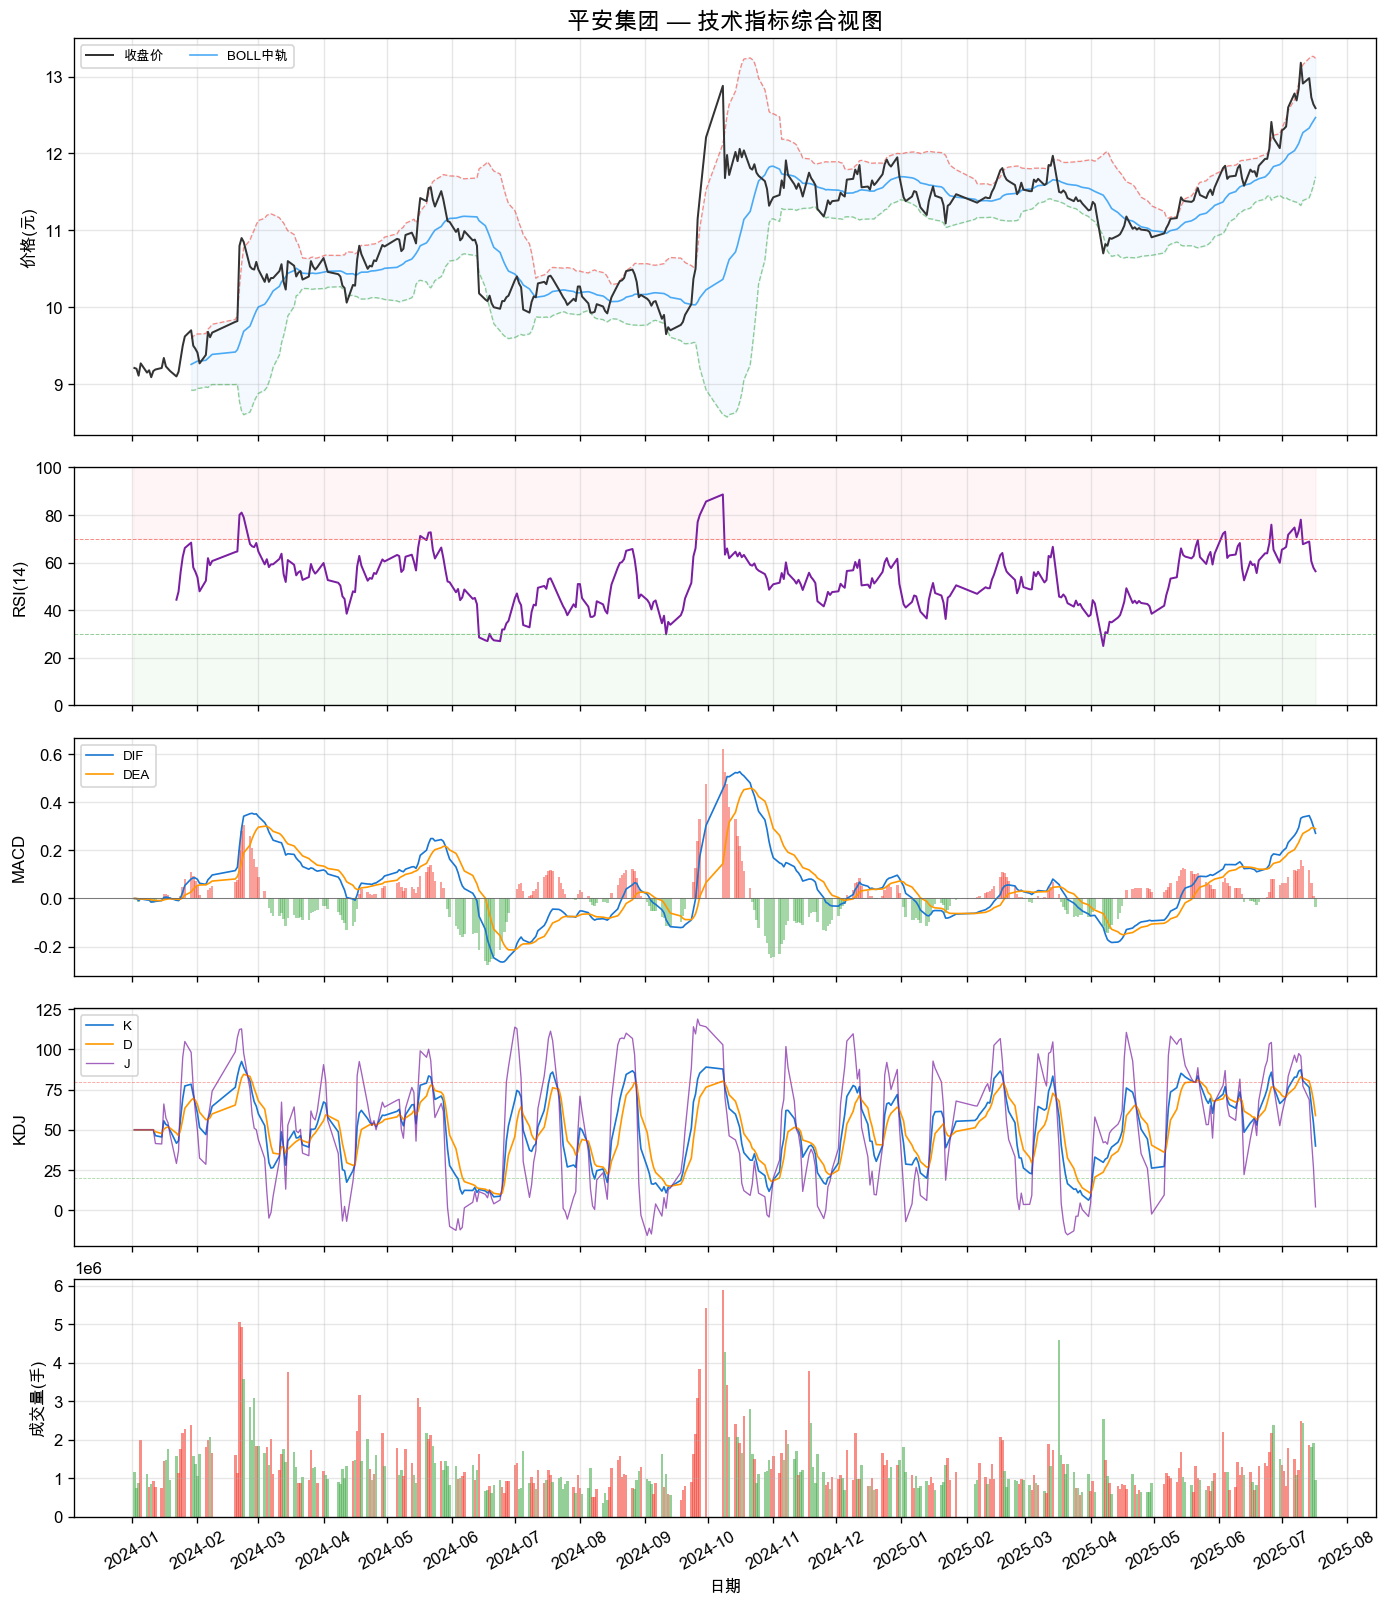

In [29]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), height_ratios=[2.5, 1.5, 1.5, 1.5, 1.5],
                          sharex=True, gridspec_kw={'hspace': 0.12})
dates = df_pingan['trade_date']

# 1. 价格 + 布林带
ax = axes[0]
ax.plot(dates, close_pa, color='#333', linewidth=1.2, label='收盘价', zorder=3)
ax.plot(dates, boll_ma_pa, color='#2196F3', linewidth=1, label='BOLL中轨', alpha=0.8)
ax.plot(dates, boll_upper_pa, color='#F44336', linewidth=0.8, linestyle='--', alpha=0.6)
ax.plot(dates, boll_lower_pa, color='#4CAF50', linewidth=0.8, linestyle='--', alpha=0.6)
ax.fill_between(dates, boll_upper_pa, boll_lower_pa, color='#90CAF9', alpha=0.1)
ax.set_ylabel('价格(元)')
ax.set_title('平安集团 — 技术指标综合视图', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, ncol=4)
ax.grid(True, alpha=0.3)

# 2. RSI
ax = axes[1]
ax.plot(dates, rsi_pa, color='#7B1FA2', linewidth=1.2)
ax.axhline(70, color='#F44336', linewidth=0.6, linestyle='--', alpha=0.6)
ax.axhline(30, color='#4CAF50', linewidth=0.6, linestyle='--', alpha=0.6)
ax.fill_between(dates, 70, 100, color='#FFCDD2', alpha=0.2)
ax.fill_between(dates, 0, 30, color='#C8E6C9', alpha=0.2)
ax.set_ylabel('RSI(14)')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# 3. MACD
ax = axes[2]
colors_pa = ['#F44336' if v >= 0 else '#4CAF50' for v in macd_hist_pa]
ax.bar(dates, macd_hist_pa, color=colors_pa, width=1.2, alpha=0.5)
ax.plot(dates, dif_pa, color='#1976D2', linewidth=1, label='DIF')
ax.plot(dates, dea_pa, color='#FF9800', linewidth=1, label='DEA')
ax.axhline(0, color='#666', linewidth=0.5)
ax.set_ylabel('MACD')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# 4. KDJ
ax = axes[3]
ax.plot(dates, k_pa, color='#1976D2', linewidth=1, label='K')
ax.plot(dates, d_pa, color='#FF9800', linewidth=1, label='D')
ax.plot(dates, j_pa, color='#7B1FA2', linewidth=0.8, label='J', alpha=0.7)
ax.axhline(80, color='#F44336', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axhline(20, color='#4CAF50', linewidth=0.5, linestyle='--', alpha=0.5)
ax.set_ylabel('KDJ')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# 5. 成交量
ax = axes[4]
vol_colors = ['#F44336' if df_pingan['pct_chg'].iloc[i] >= 0 else '#4CAF50' for i in range(len(df_pingan))]
ax.bar(dates, df_pingan['vol'], color=vol_colors, width=1.2, alpha=0.6)
ax.set_ylabel('成交量(手)')
ax.set_xlabel('日期')
ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('平安集团_综合指标图.png', bbox_inches='tight')
plt.show()

---

## 8. 结果总结

### 指标计算逻辑回顾

| 指标 | 核心计算 | 关键参数 | 信号 |
|------|----------|----------|------|
| **RSI** | 平均涨幅/平均跌幅 → 0~100 | 14日 | >70超买, <30超卖 |
| **MACD** | EMA(12)-EMA(26) → DIF, DEA | 12,26,9 | 金叉买入, 死叉卖出 |
| **布林带** | MA(20) ± 2σ | 20,2 | 触轨反转, 带宽突破 |
| **KDJ** | RSV→K→D→J | 9,3,3 | >80超买, <20超卖 |

### 最近交易日指标快照

| 股票 | 日期 | 收盘价 | RSI | DIF | DEA | K | D | J | 信号 |
|------|------|--------|-----|-----|------|---|---|---|------|
| 三一重工 | 2025-07-16 | 18.71 | 55.6 | 0.1559 | 0.0609 | 67.4 | 74.6 | 52.9 | 中性偏弱 |
| 平安集团 | 2025-07-17 | 12.59 | 56.4 | 0.2715 | 0.2900 | 39.9 | 58.9 | 2.1 | J≈0 极度超卖 |

### 关键发现

1. **平安集团** J 值降至 2.1，处于极度超卖区域，同时 MACD 柱由正转负（-0.037），短期有调整压力但反弹可能临近
2. **三一重工** 各指标处于中性区域，无明显超买超卖信号
3. 平安集团波动性明显大于三一重工（单日最大涨跌幅 ±9.98% vs ±6.28%）
4. 多指标配合使用比单一指标更可靠，建议结合趋势指标（MACD）和振荡指标（RSI/KDJ）综合判断

> ⚠️ 本报告数据仅供学习参考，不构成投资建议。